# Object Detection Project

## Russian License Plate Blurring

Welcome to your object detection project! Your goal will be to use Haar Cascades to blur license plates detected in an image!

----


#### Ways to Approach this project:
* Use the given image (car_plate.jpg) and create a function that will blur the image of its license plate. Check out the correct pre-trained .xml file (given) to use.
* Use this notebook! Here we offer a guide of what main steps you should take to complete the project.


**TASK: Import the usual libraries you think you'll need.**

In [1]:
# Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Enable inline plotting (Jupyter Notebook)
%matplotlib inline


**TASK: Read in the car_plate.jpg file from the repo.**

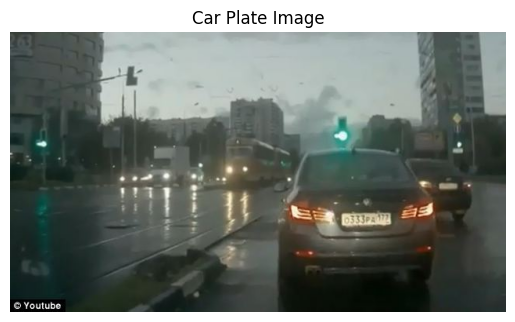

In [5]:
# Read the car plate image from repository

import cv2
import matplotlib.pyplot as plt

# Image path
imagePath = "car_plate.jpg.jpeg"

# Read image
image = cv2.imread(imagePath)

# Convert BGR to RGB
imageRGB = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display image
plt.imshow(imageRGB)
plt.title("Car Plate Image")
plt.axis("off")
plt.show()


**TASK: Create a function that displays the image in a larger scale and correct coloring for matplotlib.**

In [11]:
# Function to display image with correct color and larger size

def display_image(image):

    # Convert BGR to RGB
    imgRGB = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Set larger figure size
    plt.figure(figsize=(12,8))

    # Display image
    plt.imshow(imageRGB)

    # Remove axis
    plt.axis("off")

    # Show image
    plt.show()

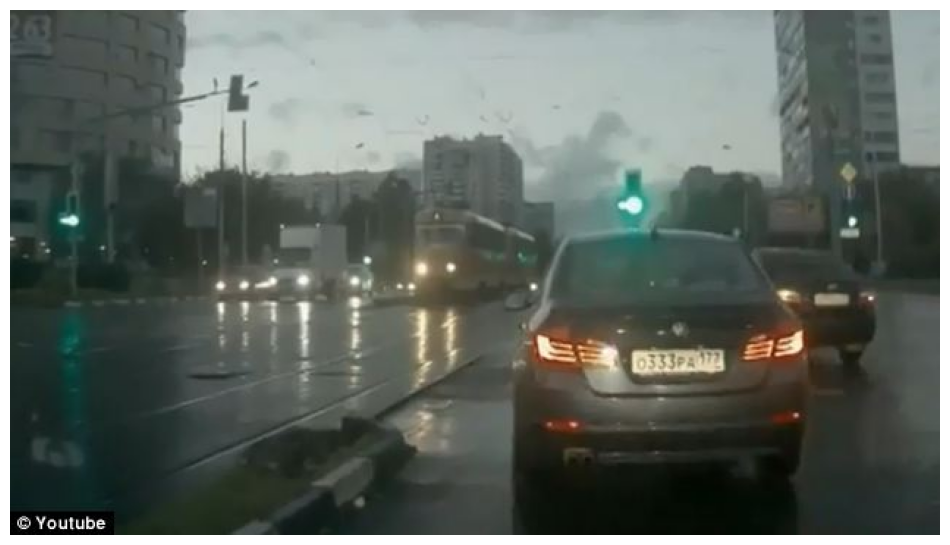

In [13]:
display_image(image)

**TASK: Load the haarcascade_russian_plate_number.xml file.**

In [14]:
plateCascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_russian_plate_number.xml"
)

**TASK: Create a function that takes in an image and draws a rectangle around what it detects to be a license plate. Keep in mind we're just drawing a rectangle around it for now, later on we'll adjust this function to blur. You may want to play with the scaleFactor and minNeighbor numbers to get good results.**

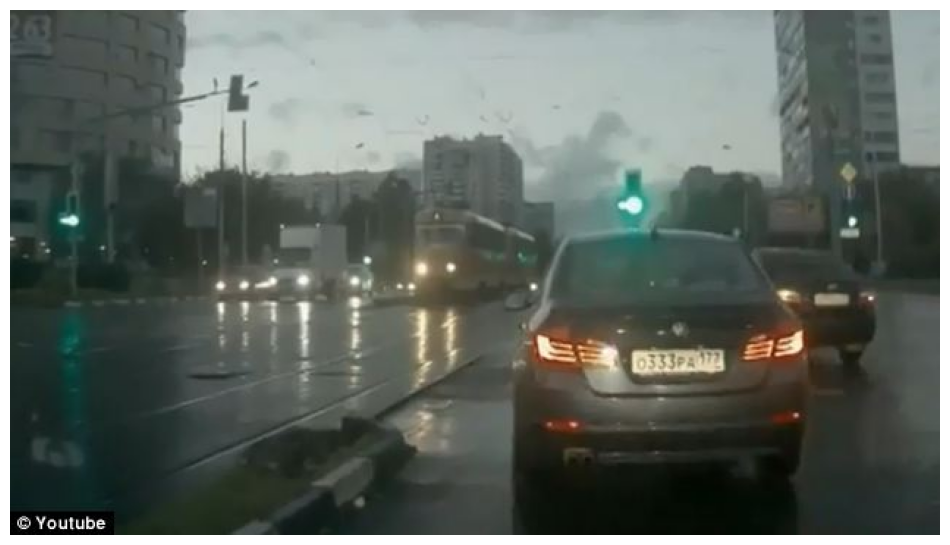

In [18]:
import cv2
import matplotlib.pyplot as plt

# Load cascade classifier correctly
plateCascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_russian_plate_number.xml"
)

# Function to display image
def display_image(image):

    imgRGB = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12,8))
    plt.imshow(imageRGB)
    plt.axis("off")
    plt.show()

# Read image
image = cv2.imread("car_plate.jpg.jpeg")

# Detection function
def detect_plate(image):

    plate_img = image.copy()

    gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)

    plates = plateCascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    for (x, y, w, h) in plates:

        cv2.rectangle(
            plate_img,
            (x, y),
            (x + w, y + h),
            (0, 255, 0),
            3
        )

    return plate_img

# Detect plate
result = detect_plate(image)

# Display output
display_image(result)

**FINAL TASK: Edit the function so that is effectively blurs the detected plate, instead of just drawing a rectangle around it. Here are the steps you might want to take:**

1. The hardest part is converting the (x,y,w,h) information into the dimension values you need to grab an ROI. you just need to convert the information about the top left corner of the rectangle and width and height, into indexing position values.
2. Once you've grabbed the ROI using the (x,y,w,h) values returned, you'll want to blur that ROI. You can use cv2.medianBlur for this.
3. Now that you have a blurred version of the ROI (the license plate) you will want to paste this blurred image back on to the original image at the same original location. Simply using Numpy indexing and slicing to reassign that area of the original image to the blurred roi.

In [19]:


def detect_and_blur_plate(image):

    # Create image copy
    plate_img = image.copy()

    # Convert to grayscale
    gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)

    # Detect plates
    plates = plateCascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    # Loop through detected plates
    for (x, y, w, h) in plates:

        # Extract ROI (Region of Interest)
        roi = plate_img[y:y+h, x:x+w]

        # Apply blur to ROI
        blurred_roi = cv2.medianBlur(roi, 31)

        # Replace original plate with blurred version
        plate_img[y:y+h, x:x+w] = blurred_roi

    return plate_img
    

In [4]:
# Detect and blur the license plate
result = detect_and_blur_plate(image)

# Display output
display_image(result)

AttributeError: 'NoneType' object has no attribute 'copy'